# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

The data represents 17 marketing campaigns by a Portuguese retail bank from May 2008 to November 2010.

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [239]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline


from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.svm import SVC

import time
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, RocCurveDisplay
from sklearn.inspection import permutation_importance
from sklearn import set_config
# Set color scheme
colors = sns.color_palette('Pastel1')
sns.set_palette('Pastel1')

# Supress warnings
import os
os.environ["PYDEVD_DISABLE_FILE_VALIDATION"] = "1"

warnings.simplefilter(action='ignore', category=FutureWarning)
set_config("display")
plt.rcParams.update({'font.size': 12})
RANDOM_STATE = 42

In [240]:
# Read in the data
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [241]:
# Check number of entrys and data types for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [242]:
# Drop 'duration' column because we are building a realistic predictive model, not a benchmark model
bank = df.drop(columns=['duration'])
# Rename column 'y' to 'subscribe'
bank = bank.rename(columns={'y': 'subscribe', 'campaign': 'no_of_contacts'}) 


In [243]:
# Check missing values
bank.isnull().sum().sort_values()

age               0
euribor3m         0
cons.conf.idx     0
cons.price.idx    0
emp.var.rate      0
poutcome          0
previous          0
pdays             0
no_of_contacts    0
day_of_week       0
month             0
contact           0
loan              0
housing           0
default           0
education         0
marital           0
job               0
nr.employed       0
subscribe         0
dtype: int64

In [244]:
# Check sample rows
bank.sample(5)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,no_of_contacts,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,subscribe
40143,29,admin.,single,university.degree,no,yes,no,cellular,jul,wed,1,999,0,nonexistent,-1.7,94.215,-40.3,0.840,4991.6,yes
1326,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,3,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
21081,37,technician,single,professional.course,no,yes,no,cellular,aug,thu,2,999,0,nonexistent,1.4,93.444,-36.1,4.964,5228.1,no
10938,45,blue-collar,divorced,unknown,unknown,yes,no,telephone,jun,wed,2,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
5577,36,admin.,married,university.degree,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [245]:
# Identify numerical and categorical column names
cat_features = bank.select_dtypes(include=["object", "category"]).columns.tolist()
num_features = bank.select_dtypes(include=[np.number]).columns.tolist()

# Remove target variable from categorical features list
cat_features.remove('subscribe')  
print("Categorical columns:", cat_features)
print("Numerical columns:", num_features)

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Numerical columns: ['age', 'no_of_contacts', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


In [246]:
# Check target variable distribution
bank['subscribe'].value_counts(normalize=True)

subscribe
no     0.887346
yes    0.112654
Name: proportion, dtype: float64

Imbalanced classes with 11.27% 'yes' responses.

#### Examine target and categorical data distributions.

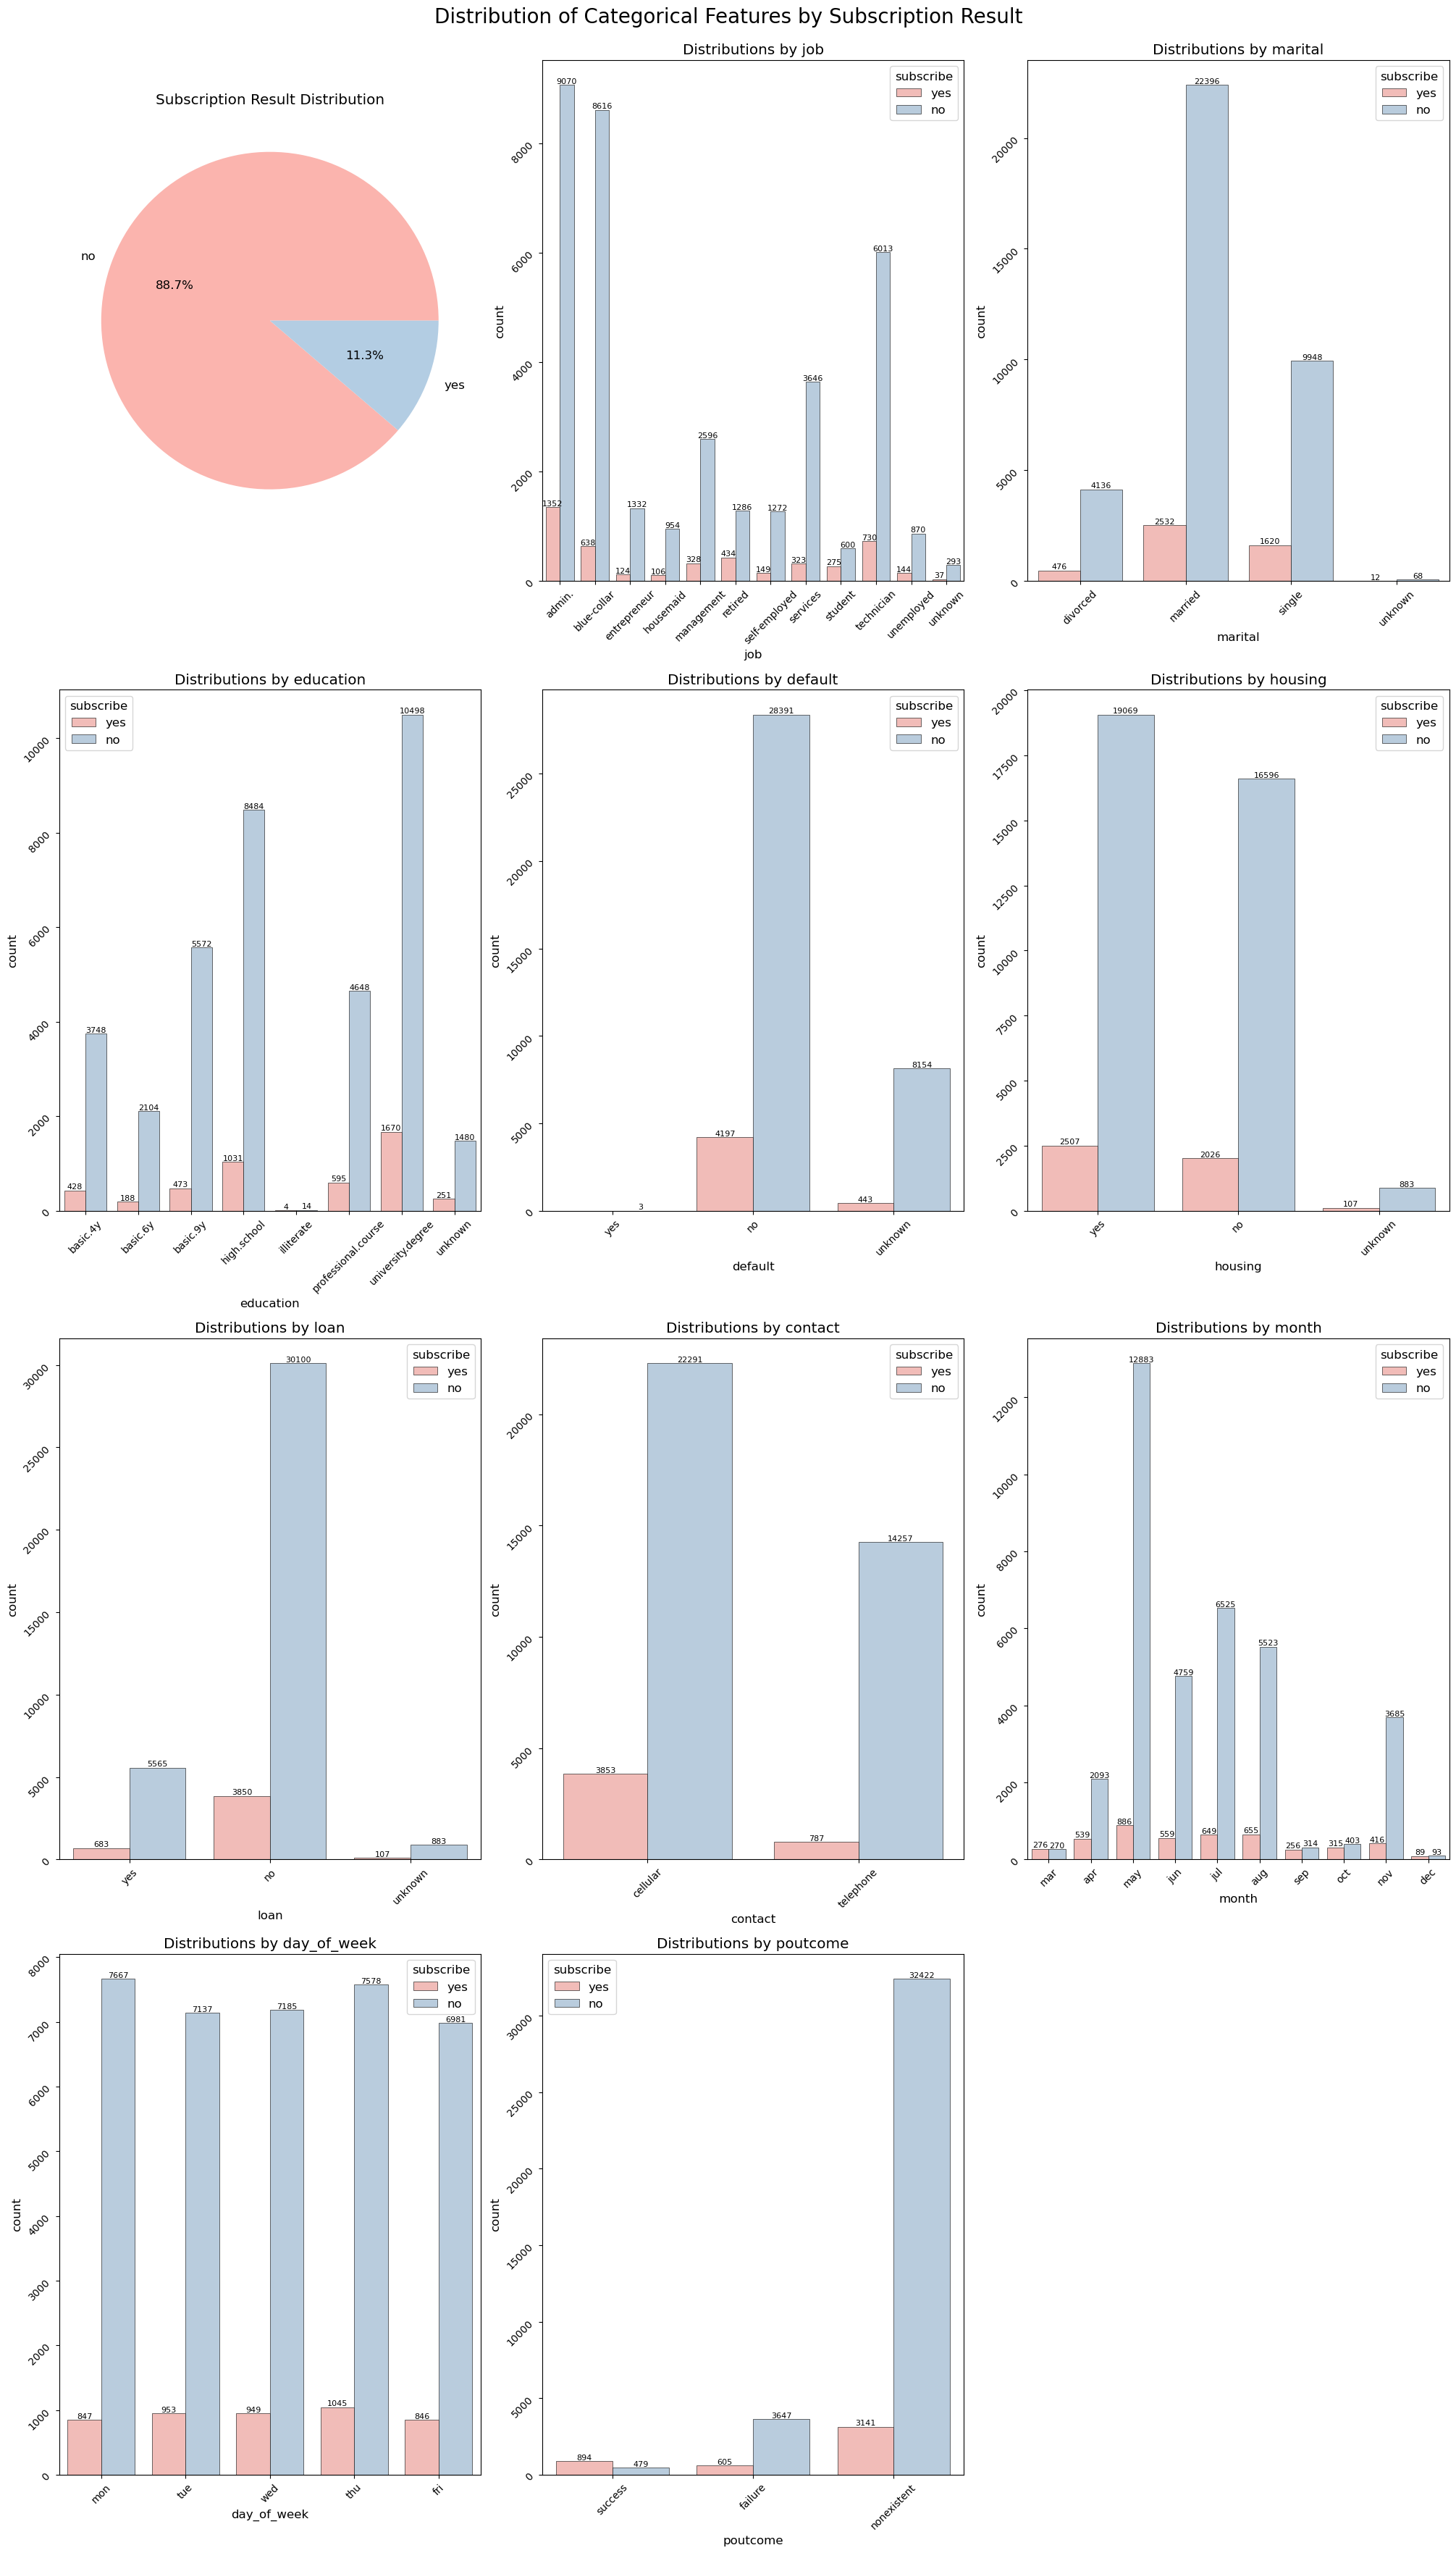

In [247]:
bank["subscribe"] = pd.Categorical(bank['subscribe'], categories=['yes', 'no'])
# Set up subplots
fig,_axes = plt.subplots(nrows=4, ncols=3, figsize=(20, 35), layout='constrained')
axes=_axes.flatten()

# Delete unused subplot and adjust spacing
fig.delaxes(axes[-1]) 

# Plot distribution of target variable 'subscribe' 

axes[0].pie(bank['subscribe'].value_counts(), labels=bank['subscribe'].value_counts().index, autopct='%1.1f%%', colors=colors)
axes[0].set_title('Subscription Result Distribution')

# Plot distributions of categorical features by subscription result
i=1
for col in cat_features:
    order = bank[col].value_counts().index.to_list()
    if (col =='default' or col == 'housing' or col == 'loan'):
        order = ['yes','no', 'unknown']
    elif col == 'month':
        order = [ 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
    elif col == 'day_of_week':
        order = ['mon', 'tue', 'wed', 'thu', 'fri']
    elif col == 'poutcome':
        order = ['success', 'failure', 'nonexistent']
    else: 
        order.sort()
    bank[col] = pd.Categorical(bank[col], order)
    ax = sns.countplot(data =bank, x=col, edgecolor='black', linewidth=0.4, ax=axes[i], hue='subscribe')
    for container in ax.containers:
        ax.bar_label(container, label_type='edge',fontsize=8)
    ax.tick_params(labelrotation=45, labelsize=10)
    ax.set_title(f'Distributions by {col}')
    i=i+1
    
plt.suptitle('Distribution of Categorical Features by Subscription Result', fontsize=20, verticalalignment='center')
plt.show()

In [120]:
# Replace 'unknown' with NaN 
bank.replace('unknown', np.nan, inplace=True)

In [121]:
# Proportion of missing values in each column
bank.isnull().sum().sort_values()/bank.shape[0]

age               0.000000
euribor3m         0.000000
cons.conf.idx     0.000000
cons.price.idx    0.000000
emp.var.rate      0.000000
poutcome          0.000000
previous          0.000000
pdays             0.000000
no_of_contacts    0.000000
day_of_week       0.000000
month             0.000000
contact           0.000000
nr.employed       0.000000
subscribe         0.000000
marital           0.001942
job               0.008012
loan              0.024036
housing           0.024036
education         0.042027
default           0.208726
dtype: float64

In [ ]:
# Check identical values in 'default' column
print(bank['default'].value_counts(normalize=True) ,"\n" )

default
no     0.999908
yes    0.000092
Name: proportion, dtype: float64 



Drop `default` column because most of the entries have mostly indentical values. Drop rows with `education` equal to `illiterate` because the data entries are too few.  

In [ ]:
# Drop 'default' column
bank.drop(columns = ['default'], inplace=True)
cat_features.remove('default')

# Drop rows with 'education' == 'illiterate' because the visualization shows that the data are too rare
indices_to_drop = bank[bank['education'] == 'illiterate'].index
bank = bank.drop(indices_to_drop)

#### Examine numerical data distributions.

In [126]:
# Check basic stastistics of numerical features
bank.describe()

,age,no_of_contacts,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41170.000000,41170.000000,41170.000000,41170.000000,41170.000000,41170.000000,41170.000000,41170.000000,41170.000000
mean,40.020355,2.567719,962.483605,0.172990,0.081980,93.575777,-40.502842,3.621337,5167.033838
std,10.419647,2.770421,186.890849,0.494964,1.570904,0.578798,4.627973,1.734444,72.255836
min,17.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


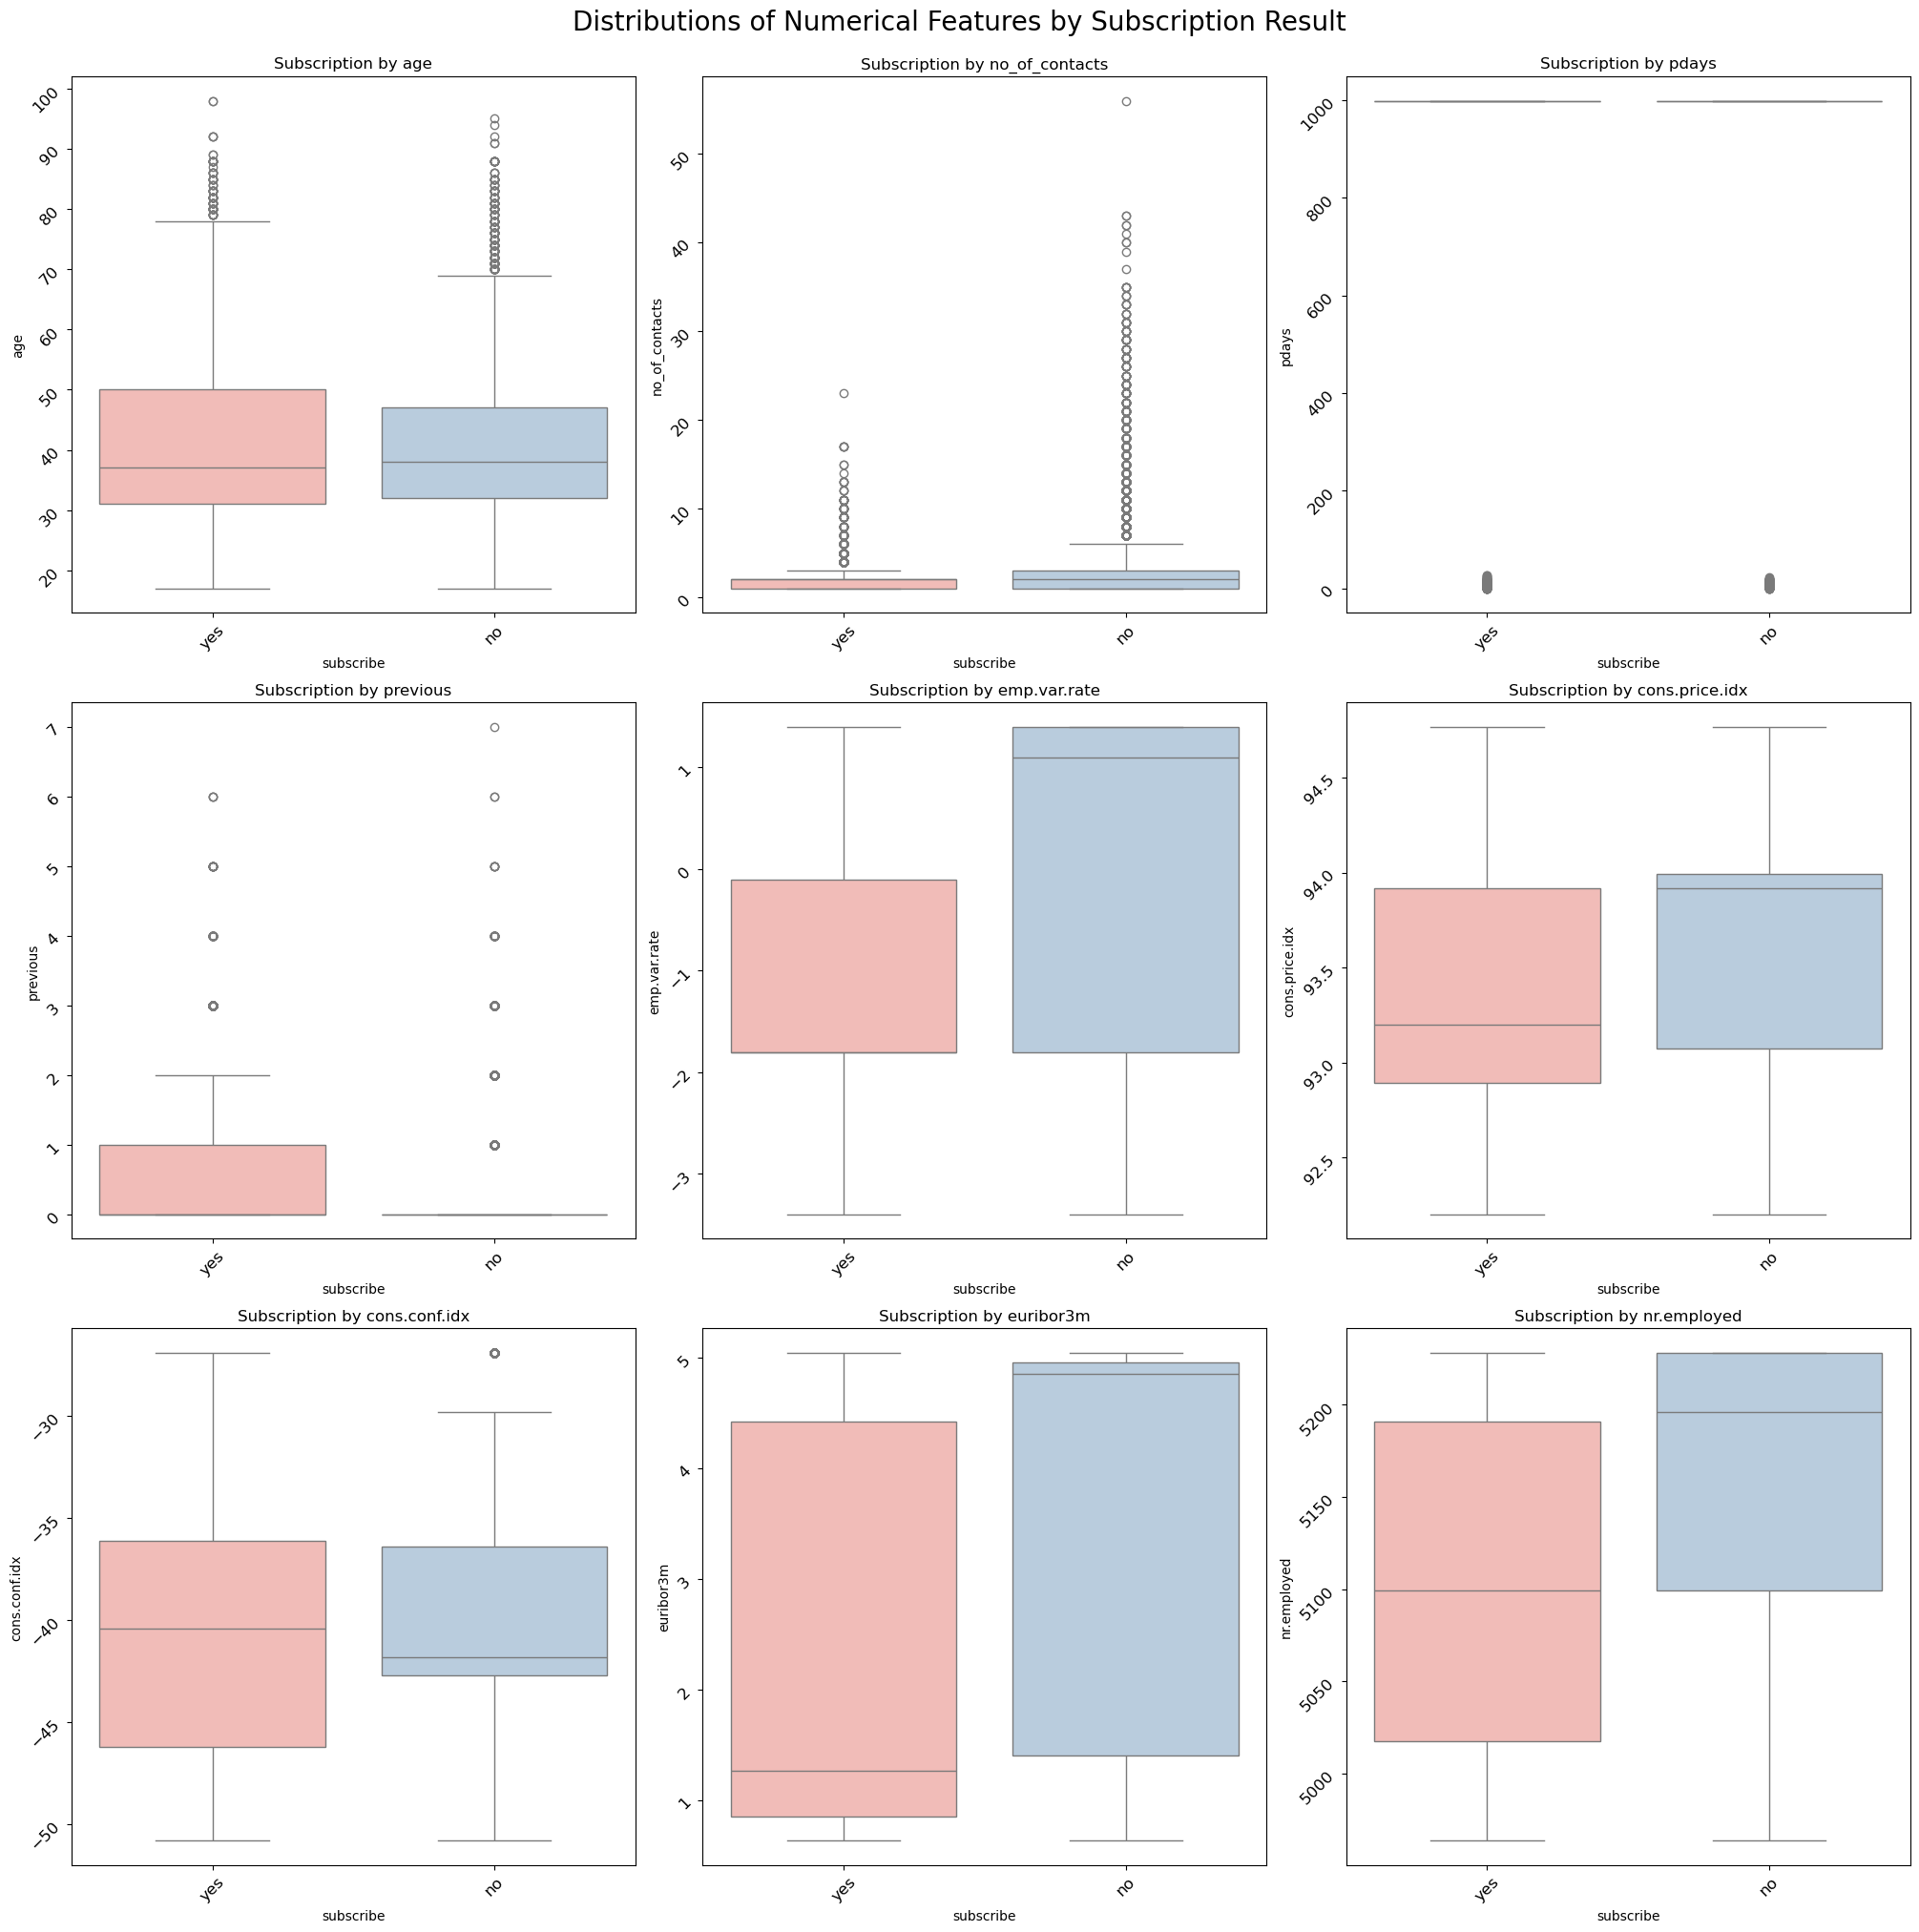

In [ ]:
# Set up subplots
fig,_axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 20), layout='constrained')
axes=_axes.flatten()
# Delete unused subplots

i=0
hue_order = ['yes', 'no'] 
for col in num_features:
    ax = sns.boxplot(data =bank, y =col, ax=axes[i],  x = 'subscribe' , hue='subscribe', hue_order=hue_order)
    ax.tick_params(labelrotation=45, labelsize=12)
    ax.set_title(f'Distriubtions by {col}')
    i=i+1

plt.suptitle('Distributions of Numerical Features by Subscription Result', fontsize=20, verticalalignment='center')
plt.show()

In [ ]:
# Check if 'previous' and 'pday' have mostly the same values
proportion_previous_0 = bank.query('previous == 0').shape[0]/bank.shape[0]
proportion_pdays_999 = bank.query('pdays == 999').shape[0]/bank.shape[0]

print (f" {proportion_previous_0:.2%} percent of entries in 'previous' have value equal to 0.")
print (f" {proportion_pdays_999:.2%} percent of entries in 'pdays' have value equal to 999.")

 86.34% percent of entries in 'previous' have value equal to 0.
 96.32% percent of entries in 'pdays' have value equal to 999.


In [ ]:
# Check distribution of 'poutcome'
bank['poutcome'].value_counts(normalize=True)

poutcome
nonexistent    0.863420
failure        0.103255
success        0.033325
Name: proportion, dtype: float64

In [ ]:
# Check dependence between 'pdays' and 'poutcome'
print(f"{bank.query('pdays==999 and previous == 0 and poutcome==\"nonexistent\"').shape[0]/bank.shape[0]:.2%} of data\
 have 'pdays' == 999, 'poutcome' == 'nonexistent', and 'previous' == 0", "\n")

86.34% of data have 'pdays' == 999, 'poutcome' == 'nonexistent', and 'previous' == 0 



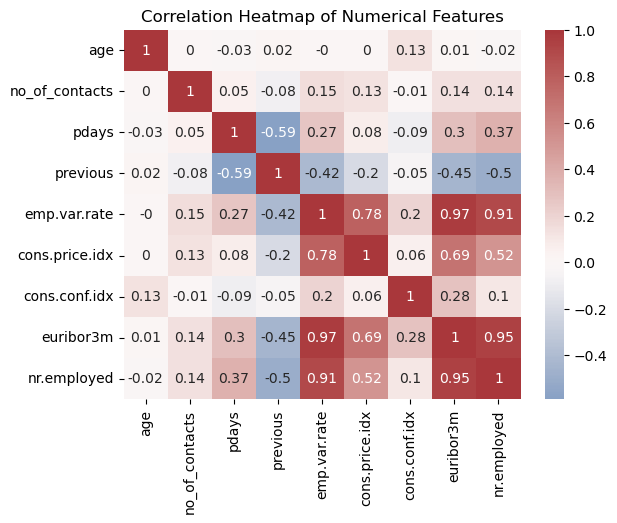

In [ ]:
# Correlation heatmap of numerical features
sns.heatmap(round(bank[num_features].corr(), 2), annot=True, center=0,cmap="vlag")
plt.title('Correlation Heatmap of Numerical Features', fontsize=12)
plt.show()


When `poutcome` is `nonexistent`, `pdays` should be 999, and `previous` should be 0, this means that  `pdays` is errorneous since there are 96% value == 999 while only 86% data of'poutcome' is 'nonexistent'.

- Drop `pdays`.
- Drop `euribor3m` because its correlations with `emp.var.rate` and `nr.employed` are >0.95.
- Drop `nr.employed` as it is directly related to `emp.var.rate`.

In [ ]:
# Remove 'previous', 'pdays', 'euribor3m', and 'nr.employed' columns
features_to_remove = ['pdays', 'euribor3m', 'nr.employed']
bank.drop(columns=features_to_remove, inplace=True)
for feature in features_to_remove: num_features.remove(feature)
num_features

['age',
 'no_of_contacts',
 'previous',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx']

Apply IQR to the remaining numerical features to remove outliers, skipping features with highly skewed distributions.

In [ ]:
# Remove outliers for numerical columns using IQR method
IQR_features = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx']
previous_data_size = bank.shape[0]
for col in IQR_features: 
    Q1 = bank[col].quantile(0.25)
    Q3 = bank[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    bank = bank[(bank[col] >= lower_bound) & (bank[col] <= upper_bound)]

# Check resulting data after outliers and unreasonable data rows are removed
bank.info()
print(f"\nThis removes {(previous_data_size - bank.shape[0])/previous_data_size*100:.2f}% of the data.")

<class 'pandas.core.frame.DataFrame'>
Index: 40723 entries, 0 to 41187
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             40723 non-null  int64   
 1   job             40399 non-null  category
 2   marital         40645 non-null  category
 3   education       39012 non-null  category
 4   housing         39745 non-null  category
 5   loan            39745 non-null  category
 6   contact         40723 non-null  category
 7   month           40723 non-null  category
 8   day_of_week     40723 non-null  category
 9   no_of_contacts  40723 non-null  int64   
 10  previous        40723 non-null  int64   
 11  poutcome        40723 non-null  category
 12  emp.var.rate    40723 non-null  float64 
 13  cons.price.idx  40723 non-null  float64 
 14  cons.conf.idx   40723 non-null  float64 
 15  subscribe       40723 non-null  category
dtypes: category(10), float64(3), int64(3)
memory usage: 2.6 MB

Thi

In [ ]:
# Check missing values
bank.isnull().sum().sort_values()

age                  0
contact              0
month                0
day_of_week          0
no_of_contacts       0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
subscribe            0
marital             78
job                324
housing            978
loan               978
education         1711
dtype: int64

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

The business objective is to find a machine learning model which explains the factors contributing to a sucessful marketing campaign through calling potentional customers, so that business managers can allocate resources efficiently to target customrs who are most likely to subscribe to the bank product.

In [135]:
bank.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40723 entries, 0 to 41187
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             40723 non-null  int64   
 1   job             40399 non-null  category
 2   marital         40645 non-null  category
 3   education       39012 non-null  category
 4   housing         39745 non-null  category
 5   loan            39745 non-null  category
 6   contact         40723 non-null  category
 7   month           40723 non-null  category
 8   day_of_week     40723 non-null  category
 9   no_of_contacts  40723 non-null  int64   
 10  previous        40723 non-null  int64   
 11  poutcome        40723 non-null  category
 12  emp.var.rate    40723 non-null  float64 
 13  cons.price.idx  40723 non-null  float64 
 14  cons.conf.idx   40723 non-null  float64 
 15  subscribe       40723 non-null  category
dtypes: category(10), float64(3), int64(3)
memory usage: 2.6 MB


### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [136]:
# Define features (X) and target (y)
X = bank.drop(columns=['subscribe'])
y = bank['subscribe']

# Encode the target variable
le = LabelEncoder()
y = le.fit_transform(y)

In [137]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features),
    ],
    remainder="drop"
)

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [155]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [ ]:
# Use a dummy classifier as baseline model

baseline_pipe= Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", DummyClassifier(strategy='most_frequent') )
])

baseline_pipe.fit(X_train, y_train)
train_preds = baseline_pipe.predict(X_train)
test_preds = baseline_pipe.predict(X_test)
baseline_proba = baseline_pipe.predict_proba(X_test)[:, 1]

# Calculate baseline model scores
baseline_train_score = accuracy_score(y_train, train_preds)
baseline_test_score = accuracy_score(y_test, test_preds)

#Print baseline model scores
print("Our classifier should perform better than the baseline model performances below:")
print(f"Baseline Train Accuracy: {baseline_train_score:.3}")
print(f"Baseline Test Accuracy: {baseline_test_score:.3}")


Our classifier should perform better than the baseline model performances below:
Baseline Train Accuracy: 0.89
Baseline Test Accuracy: 0.892


### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [248]:
# Makes a default logistic regression pipeline model
lr_simple=LogisticRegression()
lr_simple_pipe = make_pipeline(preprocessor, lr_simple)

# Fit the model
lr_simple_pipe.fit(X_train, y_train)

# Comupute scores
train_preds = lr_simple_pipe.predict(X_train)
test_preds = lr_simple_pipe.predict(X_test)
lr_simple_proba = lr_simple_pipe.predict_proba(X_test)[:, 1]

lr_simple_train_score = accuracy_score(y_train, train_preds)
lr_simple_test_score = accuracy_score(y_test, test_preds)
lr_simple_f1_score = f1_score(y_test, test_preds)
lr_simple_roc_auc_score = roc_auc_score(y_test, lr_simple_proba)

# Print scores
print(f"Simple Logistic Regression Train Accuracy: {lr_simple_train_score:.3}")
print(f"Simple Logistic Regression Test Accuracy: {lr_simple_test_score:.3}")
print(f"Simple Logistic Regression Test F1 Score: {lr_simple_f1_score:.3}")
print(f"Simple Logistic Regression Test ROC AUC Score: {lr_simple_roc_auc_score:.3}")

Simple Logistic Regression Train Accuracy: 0.901
Simple Logistic Regression Test Accuracy: 0.909
Simple Logistic Regression Test F1 Score: 0.374
Simple Logistic Regression Test ROC AUC Score: 0.792


The simple logistic regression model performs better than the dummy classifier model.

### Problem 9: Score the Model

What is the accuracy of your model?

In [249]:
print(f"Simple Logistic Regression Train Accuracy: {lr_simple_train_score:.3}")
print(f"Simple Logistic Regression Test Accuracy: {lr_simple_test_score:.3}")

Simple Logistic Regression Train Accuracy: 0.901
Simple Logistic Regression Test Accuracy: 0.909


### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [250]:
# Define the default models
models_default = {
    'Default Logistic Regression': lr_simple,
    'Default KNN': KNeighborsClassifier(),
    'Default Decision Tree': DecisionTreeClassifier(), 
    'Default SVM': SVC()
}

In [251]:
results_default = []

for name, model in models_default.items():
    # Create a pipeline
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        (name, model)
    ])
    
    start_time = time.time()
    pipe.fit(X_train, y_train)
    fit_time = time.time() - start_time

    # Evaluate on training and test sets
    train_preds = pipe.predict(X_train)
    test_preds = pipe.predict(X_test)
    train_accuracy_score = accuracy_score(y_train, train_preds)
    test_accuracy_score = accuracy_score(y_test, test_preds)
    test_precision_score = precision_score(y_test, test_preds)
    test_recall_score = recall_score(y_test, test_preds)
    test_f1_score = f1_score(y_test, test_preds)


    # Append the results
    results_default.append([name, fit_time, train_accuracy_score, test_accuracy_score, test_precision_score, test_recall_score, test_f1_score])


In [216]:
# Create the results DataFrame
results_default_df = pd.DataFrame(results_default, columns=['Model', 'Train Time (s)', 'Train Accuracy Score',\
                                                            'Test Accuracy Score', 'Test Precision Score', 'Test Recall Score', 'Test F1 Score'])
results_default_df = results_default_df.sort_values(by='Test Accuracy Score', ascending=False).reset_index(drop=True)
results_default_df[['Model', 'Train Time (s)', 'Train Accuracy Score','Test Accuracy Score']]

,Model,Train Time (s),Train Accuracy Score,Test Accuracy Score
0,Default SVM,46.863145,0.906808,0.909024
1,Default Logistic Regression,0.361853,0.901467,0.908533
2,Default KNN,0.092697,0.913346,0.895887
3,Default Decision Tree,0.205360,0.992602,0.843094


Both default logsitsic regression model and default SVM model perform better with both training data and testing data than the baseline model, but the train time for SVM is very long. KNN and decision tree classifier do not perform well with the test set.

Plot the fit time and scores across models.

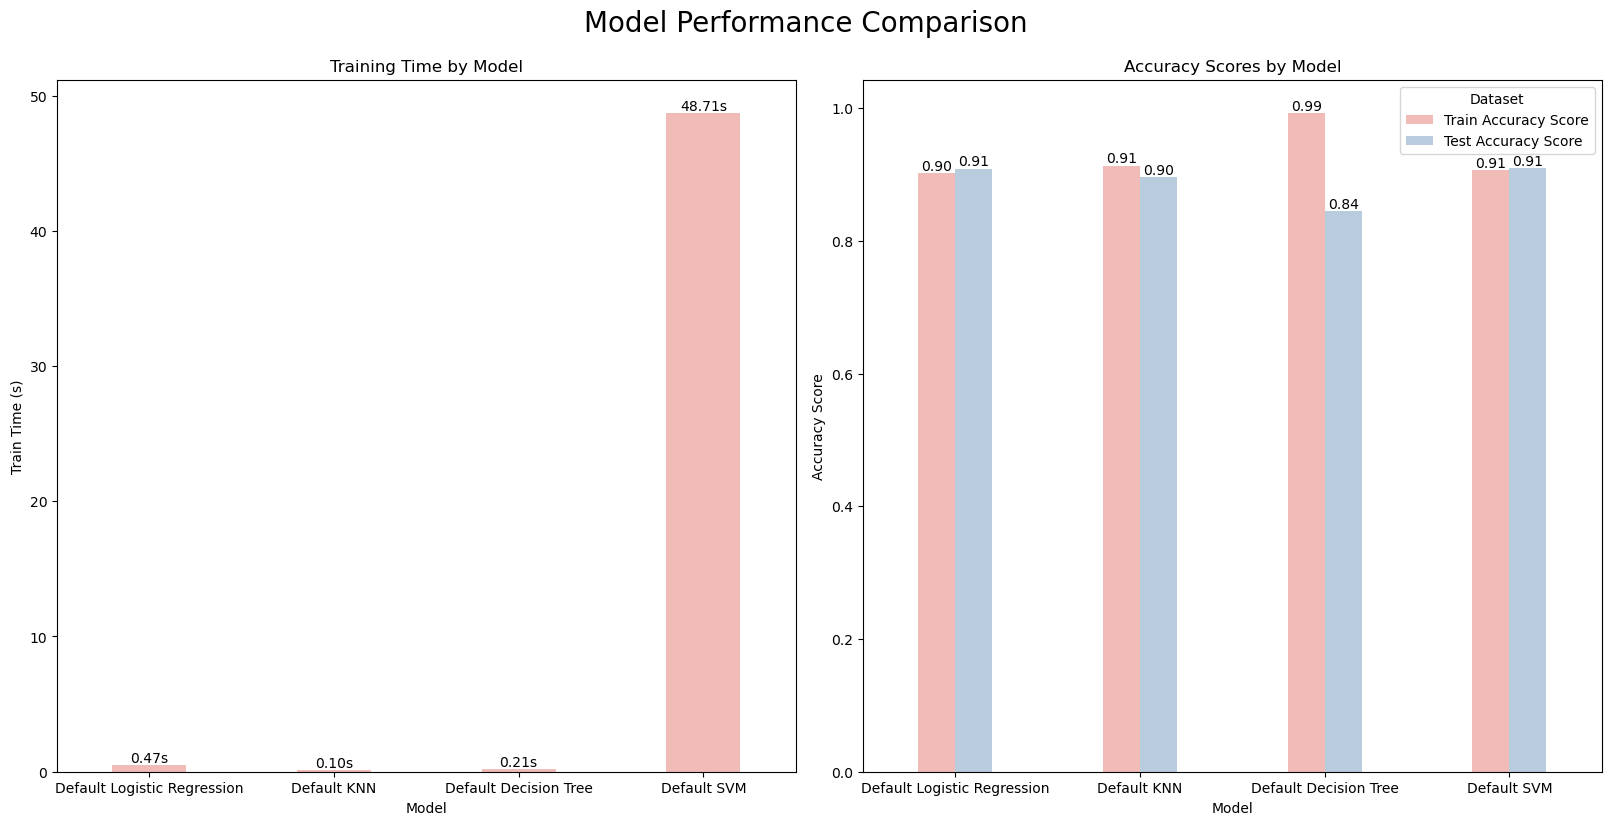

In [ ]:
# Set up subplots
fig,_axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 8), layout='constrained')
axes=_axes.flatten()

# Plot training time across models
axes[0] = sns.barplot(x='Model', y='Train Time (s)', linewidth=0.4, data=results_default_df, ax=axes[0], width=0.4)  
axes[0].set_title('Training Time by Model')
# axes[0].tick_params(labelrotation=45)
for container in axes[0].containers:
        axes[0].bar_label(container,  fmt='{:.2f}s', label_type='edge',fontsize=10)

# Plot training and test accuracy scores
results_default_melted = results_default_df.melt(id_vars='Model', value_vars=['Train Accuracy Score', 'Test Accuracy Score'], var_name='Dataset', value_name='Accuracy Score')
axes[1]=sns.barplot(x='Model', y='Accuracy Score', hue='Dataset', linewidth=0.4, data=results_default_melted, ax=axes[1], width=0.4)
axes[1].set_title('Accuracy Scores by Model')
# axes[1].tick_params(labelrotation=45)
for container in axes[1].containers:
        axes[1].bar_label(container,  fmt='{:.2f}', label_type='edge',fontsize=10)

plt.suptitle('Model Performance Comparison (Accuracy)', fontsize=20, verticalalignment='center')
plt.show()

The default SVM model has the best accuracy score for both train and test sets at 0.907 and 0.909, but it also takes the longest time to fit the train data. The default decision tree model has the best train accuracy score (=0.99), but the poorest test accuracy score(=0.84).

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [173]:
# Define models and hyperparameters
models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000), {'Logistic Regression__C': [0.1, 1, 10]}),
    'KNN': (KNeighborsClassifier(), {'KNN__n_neighbors': [3, 5, 7, 9]}),
    'Decision Tree': (DecisionTreeClassifier(), {'Decision Tree__max_depth': [4, 8, 12, 16]}), 
    'SVM': (SVC(), {'SVM__C': [0.1, 1, 10], 'SVM__kernel': ['linear', 'rbf']})
}

F1 score is chosen as it represents a balance between accurancy score and recall score for as the evaluation metrics because the dataset is unbalanced with the subscription rate euqual to 11.3%, and the goal is not to miss any potential buyer, which is to minimuze the number of false negatives, while reducing marketing cost, which is to minimize false positives. 

In [ ]:
results_grid = []
best_models = {}

for name, (model, params) in models.items():
    # Create a pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        (name, model)
    ])
    
    # Perform grid search
    grid = GridSearchCV(pipeline, param_grid=params, cv=5, n_jobs=-1, scoring='f1')
    
    # Fit the model and time it
    start_time = time.time()
    grid = grid.fit(X_train, y_train)
    fit_time = (time.time() - start_time) / len(grid.cv_results_['mean_fit_time'])
    
    # Get the best estimator
    best_models[name] = grid.best_estimator_
    best_train_score = grid.best_score_
    best_test_score = f1_score(y_test, grid.best_estimator_.predict(X_test))
    best_params = grid.best_params_

    # Append the results and best model
    results_grid.append([name, fit_time, best_train_score, best_test_score, best_params])


In [182]:
# Create the results DataFrame
results_grid_df = pd.DataFrame(results_grid, columns=['Model', 'Train Time (s)', 'Train F1 Score', 'Test F1 Score', 'Best Parameters'])
results_grid_df = results_grid_df.sort_values(by='Test F1 Score', ascending=False).reset_index(drop=True)
results_grid_df

,Model,Train Time (s),Train F1 Score,Test F1 Score,Best Parameters
0,SVM,987.860896,0.356774,0.393318,"{'SVM__C': 10, 'SVM__kernel': 'rbf'}"
1,Decision Tree,0.228232,0.332190,0.384266,{'Decision Tree__max_depth': 12}
2,Logistic Regression,1.529400,0.321591,0.374475,{'Logistic Regression__C': 1}
3,KNN,0.859077,0.341818,0.347949,{'KNN__n_neighbors': 3}


Plot the fit time and performance across models.

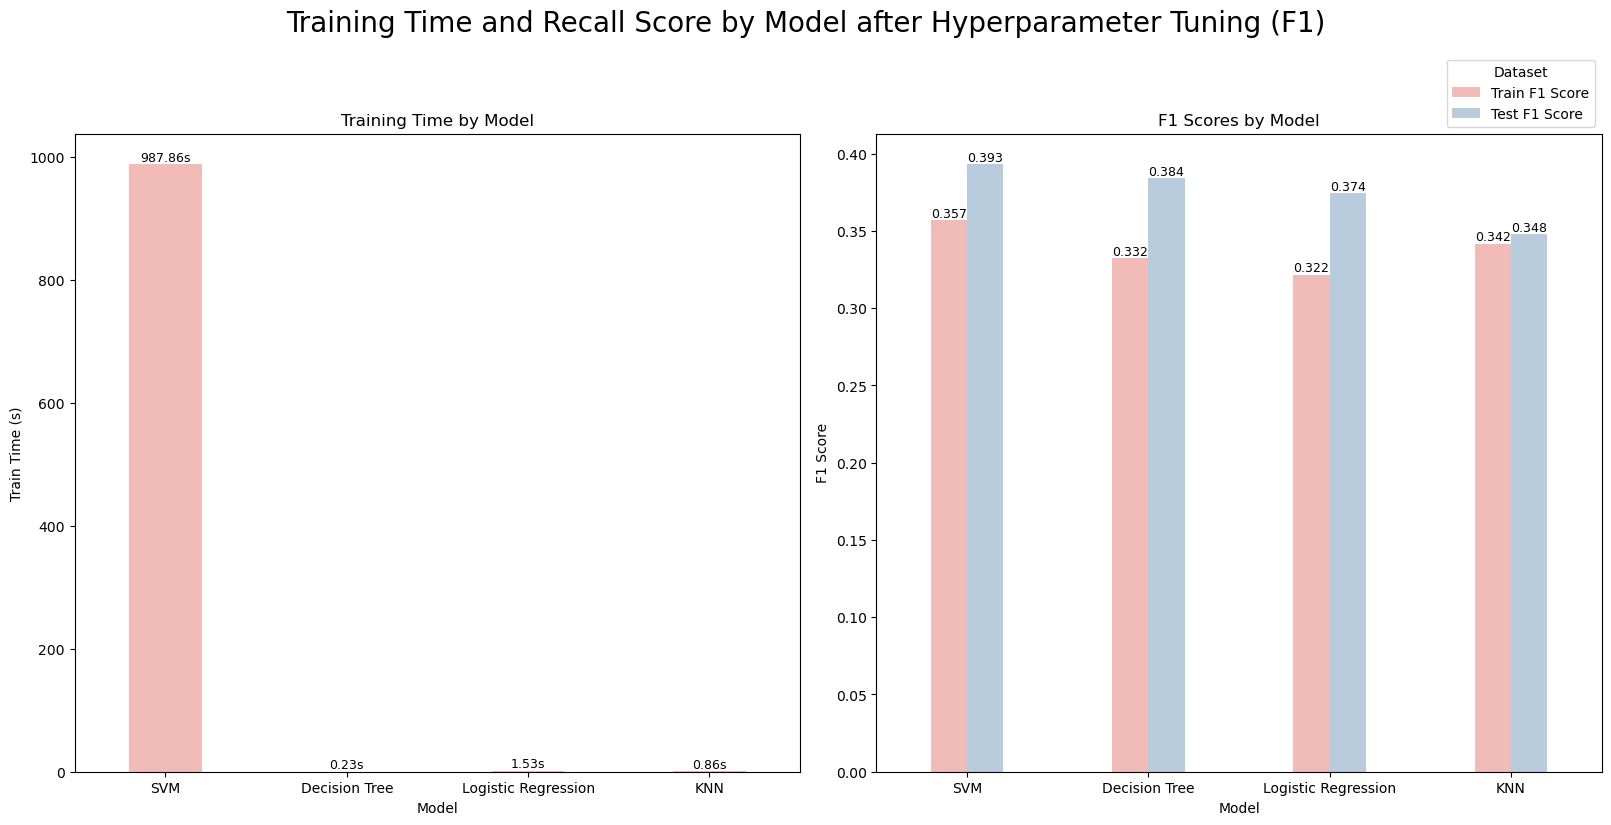

In [183]:
# Set up subplots
fig,_axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 8), layout='constrained')
axes=_axes.flatten()

# Plot training time across models
axes[0] = sns.barplot(x='Model', y='Train Time (s)', linewidth=0.4, data=results_grid_df, ax=axes[0], width=0.4)  
axes[0].set_title('Training Time by Model')
# axes[0].tick_params(labelrotation=45)
for container in axes[0].containers:
        axes[0].bar_label(container,  fmt='{:.2f}s', label_type='edge',fontsize=9)

# Plot training and test accuracy scores
results_grid_melted = results_grid_df.melt(id_vars='Model', value_vars=['Train F1 Score', 'Test F1 Score'], var_name='Dataset', value_name='F1 Score')
axes[1]=sns.barplot(x='Model', y='F1 Score', hue='Dataset', linewidth=0.4, data=results_grid_melted, ax=axes[1], width=0.4)
axes[1].set_title('F1 Scores by Model')
# axes[1].tick_params(labelrotation=45)
for container in axes[1].containers:
        axes[1].bar_label(container,  fmt='{:.3f}', label_type='edge',fontsize=9)
sns.move_legend(axes[1], "lower right", bbox_to_anchor=(1, 1), title="Dataset")
plt.suptitle('Training Time and Recall Score by Model after Hyperparameter Tuning (F1)', fontsize=20, verticalalignment='center')
plt.show()

In [184]:
# Choose the best model
final_model = best_models[results_grid_df['Model'][0]]
final_model_name = results_grid_df['Model'][0]
print("The best model is", final_model_name, "because it has the highest Test F1 Score of", \
      f"{results_grid_df['Test F1 Score'][0]:.3f}.")

The best model is SVM because it has the highest Test F1 Score of 0.393.


List features by importance based on the coefficients.

In [ ]:
#Feature importance for the best model SVM
importance = permutation_importance(final_model, X_test, y_test)

Top 5 Features (Permutation Importance):


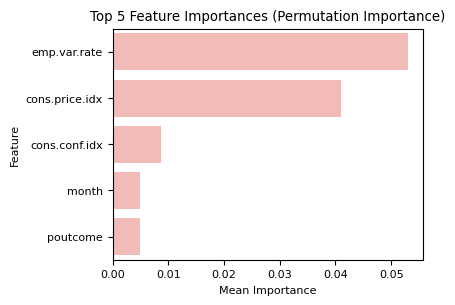

In [ ]:
# Create a datafrane table of features sorted by importance
feature_names = final_model.feature_names_in_
importance_df = pd.DataFrame({k: importance[k] for k in ("importances_mean","importances_std",)},index=feature_names)\
                                 .sort_values(by="importances_mean", ascending=False)

# Plot the top 5 important features
top_n = 5
print(f"Top {top_n} Features (Permutation Importance):")
plt.figure(figsize=(4, 3))
sns.barplot(data = importance_df.head(top_n), x = "importances_mean", y = importance_df.head(top_n).index)
plt.title(f'Top {top_n} Feature Importances (Permutation Importance)')
plt.xlabel('Mean Importance')
plt.ylabel('Feature')
plt.show()

In [223]:
importance_df

,importances_mean,importances_std
emp.var.rate,5.296501e-02,0.002745
cons.price.idx,4.100675e-02,0.001530
cons.conf.idx,8.667894e-03,0.000870
month,4.960098e-03,0.000714
poutcome,4.886433e-03,0.000475
contact,4.125230e-03,0.001446
previous,3.118478e-03,0.000457
loan,2.701044e-04,0.000273
no_of_contacts,1.718846e-04,0.000643
education,-2.220446e-17,0.000699


In [ ]:
# Calculate predictions of train and test datatsets
final_train_preds = final_model.predict(X_train)
final_test_preds = final_model.predict(X_test)

Predicted Train Subscription Rate: 5.05%
Predicted Test Subscription Rate: 5.33%
Actual Train Subscription Rate: 10.97%
Actual Test Subscription Rate: 10.84%

Final Selected Model - SVM:


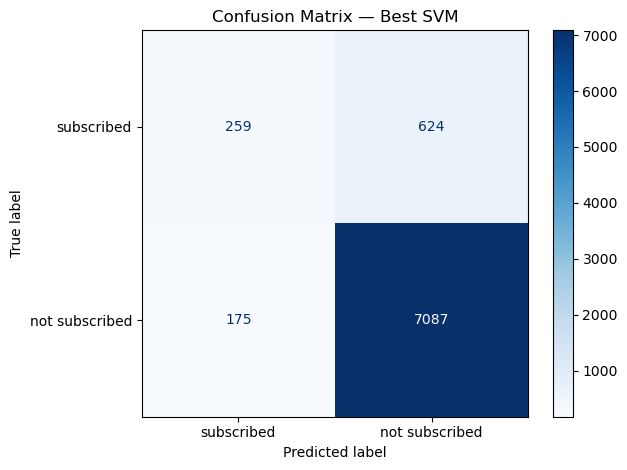

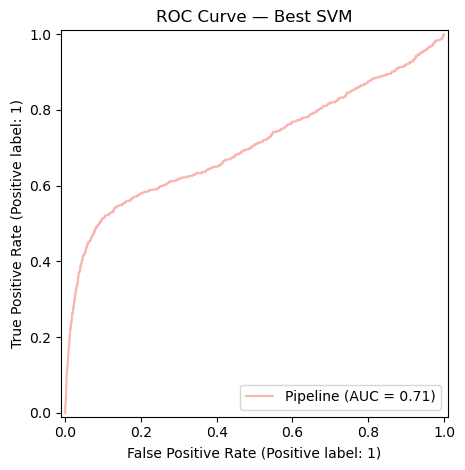

              precision    recall  f1-score   support

          no       0.92      0.98      0.95      7262
         yes       0.60      0.29      0.39       883

    accuracy                           0.90      8145
   macro avg       0.76      0.63      0.67      8145
weighted avg       0.88      0.90      0.89      8145



In [218]:
# Print predicted and actual subscription rates
final_train_pred_rate = sum(final_train_preds)/len(final_train_preds)
final_test_pred_rate = sum(final_test_preds)/len(final_test_preds)
actual_train_rate = sum(y_train)/len(y_train)
actual_test_rate = sum(y_test)/len(y_test)
print(f"Predicted Train Subscription Rate: {final_train_pred_rate:.2%}")
print(f"Predicted Test Subscription Rate: {final_test_pred_rate:.2%}")
print(f"Actual Train Subscription Rate: {actual_train_rate:.2%}")
print(f"Actual Test Subscription Rate: {actual_test_rate:.2%}")

print(f"\nFinal Selected Model - {final_model_name}:")
# Confusion 
bank_confusion_mat = confusion_matrix(y_test, final_test_preds, labels=[1, 0])
disp_cf = ConfusionMatrixDisplay(confusion_matrix=bank_confusion_mat, display_labels=['subscribed', 'not subscribed'])
disp_cf.plot(cmap=plt.cm.Blues, values_format='d')
plt.title(f"Confusion Matrix — Best {final_model_name}")
plt.tight_layout()
plt.show()

# ROC Curve
disp_roc =RocCurveDisplay.from_estimator(final_model, X_test, y_test)
plt.title(f"ROC Curve — Best {final_model_name}")
plt.tight_layout()
plt.show()

# Classification Report
report = classification_report(y_test, final_test_preds, target_names=['no', 'yes'])
print(report)

In [252]:
print("Scores from the Default Models:")
results_default_df

Scores from the Default Models:


,Model,Train Time (s),Train Accuracy Score,Test Accuracy Score,Test Precision Score,Test Recall Score,Test F1 Score
0,Default SVM,46.863145,0.906808,0.909024,0.723270,0.260476,0.383014
1,Default Logistic Regression,0.361853,0.901467,0.908533,0.724026,0.252548,0.374475
2,Default KNN,0.092697,0.913346,0.895887,0.538976,0.274066,0.363363
3,Default Decision Tree,0.205360,0.992602,0.843094,0.299492,0.334088,0.315846


The final selected SVM with tuned hyperparameters performs better than the default SVM (0.39 > 0.38) for the F1 score. 

The model shows that the top five most important features are:
- `emp.var.rate`	
- `cons.price.idx`	
- `cons.conf.idx`	
- `month`	
- `poutcome`	

### Findings

The best model is tuned SVM with F1 score of 0.39. The model shows that the most important factors attributing to a successful subscription are employment variation rate, consumer price index, consumer confidence index, month of contact, and outcome of previous campaign. This information shows that to improve the marketing campaign results, bank managers should pay close attention to the listsed economic markers, choose the months of highest subscription rate (March, September, October, and December) to launch the campaign, and focus on those who have been contacted before. 

### Next Steps and Recommendations

To improve the performance of the model, perhaps more features need to be included, for examples, duration of call and time of call.